In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, brier_score_loss

In [18]:
risk = pd.read_csv("risk_factors_cervical_cancer.csv",na_values='?') #NA = ? in dataset

risk_cols_q3 = [
    "Biopsy",                       # DV
    "STDs",                         # behavioural exposure
    "Number of sexual partners",    # behavioural exposure
    "Smokes",                       # control
]

risk_q3 = risk[risk_cols_q3].copy()
risk_q3.info()
risk_q3.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 858 entries, 0 to 857
Data columns (total 4 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Biopsy                     858 non-null    int64  
 1   STDs                       753 non-null    float64
 2   Number of sexual partners  832 non-null    float64
 3   Smokes                     845 non-null    float64
dtypes: float64(3), int64(1)
memory usage: 26.9 KB


,Biopsy,STDs,Number of sexual partners,Smokes
0,0,0.0,4.0,0.0
1,0,0.0,1.0,0.0
2,0,0.0,1.0,0.0
3,0,0.0,5.0,1.0
4,0,0.0,3.0,0.0


In [19]:
# Renaming this column for ease
risk_q3 = risk_q3.rename(columns={"Number of sexual partners": "num_partners",})

In [20]:
# Dropping NA
risk_q3 = risk_q3.dropna()

# Ensure all variables are numeric (force)
for col in risk_q3.columns:
    risk_q3[col] = pd.to_numeric(risk_q3[col], errors='coerce')

# Drop any new NaNs created by coercion
risk_q3 = risk_q3.dropna()

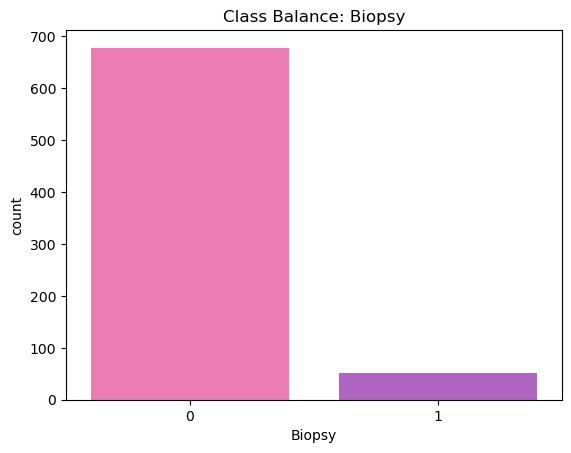

In [39]:
# Inspect class balance of biopsy outcome 
risk_q3['Biopsy'].value_counts(normalize=True) # proportions of classes
sns.countplot(data=risk_q3,x='Biopsy',hue='Biopsy',palette={0: "hotpink", 1: "mediumorchid"},legend=False)
plt.title("Class Balance: Biopsy");

       Variable       VIF
0         const  3.483101
1          STDs  1.013758
2  num_partners  1.065995
3        Smokes  1.079810


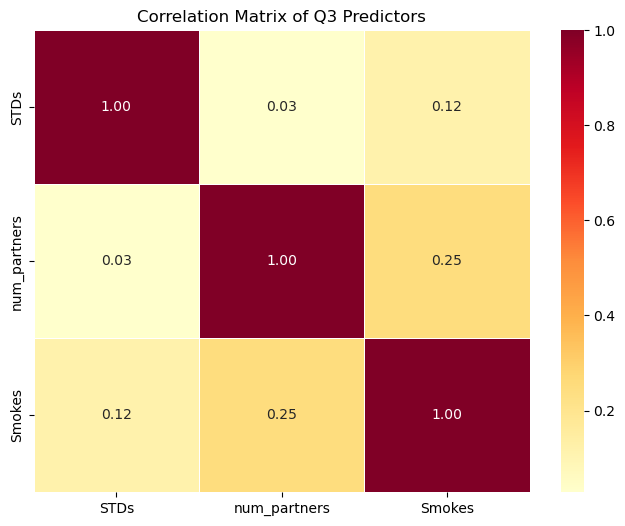

In [66]:
# Multicolliearity check 
predictors_base = [
    "STDs", 
    "num_partners",
    "Smokes",]

# VIF
X_vif = risk_q3[predictors_base].copy()
X_vif = sm.add_constant(X_vif)
vif_df_q3 = pd.DataFrame({"Variable": X_vif.columns,"VIF": [variance_inflation_factor(X_vif.values, i)for i in range(X_vif.shape[1])]})
print(vif_df_q3)

# Correlation matrix 
corr_vars = [
    "STDs",
    "num_partners",
    "Smokes",
]

corr_matrix = risk_q3[corr_vars].corr()

plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix,
    annot=True,             # show correlation values
    cmap="YlOrRd",        
    fmt=".2f",              # 2 decimal places
    linewidths=0.5
)

plt.title("Correlation Matrix of Q3 Predictors")
plt.show()

In [50]:
# Standardising continuous variables (the rest are binary)
risk_q3["num_partners_z"] = (risk_q3["num_partners"] - risk_q3["num_partners"].mean()) / risk_q3["num_partners"].std()

# Adding standardised variable to predictors
predictors_base = [
    "STDs",
    "num_partners_z",
    "Smokes"]

In [51]:
# Train test split stratifying by biopsy class
X = risk_q3[predictors_base].copy()
X = sm.add_constant(X)
y = risk_q3["Biopsy"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=22, stratify=y)

In [52]:
# Logistic regression model (BASE)
logit_train = sm.Logit(y_train, X_train).fit()
print(logit_train.summary())

Optimization terminated successfully.
         Current function value: 0.251853
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                 Biopsy   No. Observations:                  583
Model:                          Logit   Df Residuals:                      579
Method:                           MLE   Df Model:                            3
Date:                Fri, 19 Dec 2025   Pseudo R-squ.:                 0.01033
Time:                        02:27:58   Log-Likelihood:                -146.83
converged:                       True   LL-Null:                       -148.36
Covariance Type:            nonrobust   LLR p-value:                    0.3819
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -2.7281      0.192    -14.176      0.000      -3.105      -2.351
STDs             

In [53]:
# Odds Ratios + 95% CIs
params_base = logit_train.params
conf_base = logit_train.conf_int()

or_table_base = pd.DataFrame({
    "OR": np.exp(params_base),
    "2.5%": np.exp(conf_base[0]),
    "97.5%": np.exp(conf_base[1])
})
print(or_table_base)

                      OR      2.5%     97.5%
const           0.065341  0.044810  0.095279
STDs            1.978576  0.862057  4.541189
num_partners_z  0.990601  0.725080  1.353356
Smokes          1.323101  0.567394  3.085324


0.5573529411764706


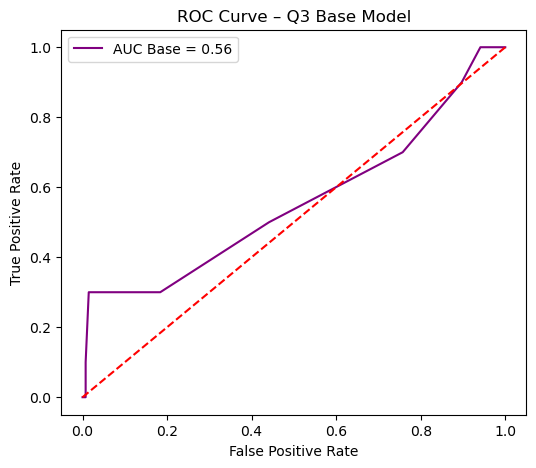

In [58]:
# ROC-AUC Test set (Base)
y_pred_prob_base = logit_base.predict(X_test)
auc_base = roc_auc_score(y_test, y_pred_prob_base)
print(auc_base)

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob_base)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC Base = {auc_base:.2f}", color="purple")
plt.plot([0,1],[0,1],"r--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Q3 Base Model")
plt.legend();

   const  STDs  num_partners_z    Smokes  pred_prob
0      1     0        0.031292  0.147513   0.063737
1      1     1        0.031292  0.147513   0.118705


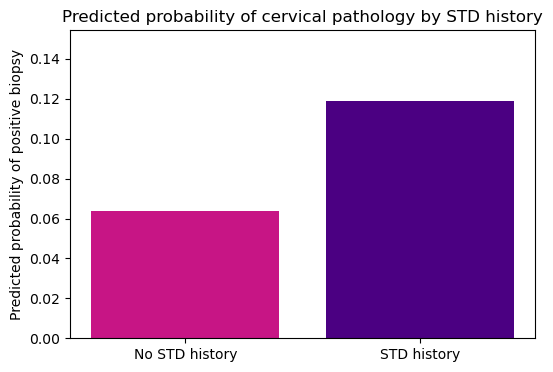

In [65]:
# Isolating the effect of STD as its the srongest associaion.
marginal_df = pd.DataFrame({
    "const": 1,
    "STDs": [0, 1],
    "num_partners_z": X_train["num_partners_z"].mean(),
    "Smokes": X_train["Smokes"].mean()})

marginal_df["pred_prob"] = logit_train.predict(marginal_df)
print(marginal_df)

plt.figure(figsize=(6,4))
plt.bar(["No STD history", "STD history"],marginal_df["pred_prob"],color=["mediumvioletred", "indigo"])

plt.ylabel("Predicted probability of positive biopsy")
plt.title("Predicted probability of cervical pathology by STD history")
plt.ylim(0, marginal_df["pred_prob"].max() * 1.3)
plt.show()


In [69]:
# Interaction model: STDs × partners 
X_train_int = X_train.copy()
X_test_int = X_test.copy()
X_train_int["STDs_x_partners"] = (X_train_int["STDs"] * X_train_int["num_partners_z"])
X_test_int["STDs_x_partners"] = (X_test_int["STDs"] * X_test_int["num_partners_z"])

# Running logistic regression for interaction model
logit_interaction = sm.Logit(y_train, X_train_int).fit()
print(logit_interaction.summary())

# ORs + CIs 
params_int = logit_interaction.params
conf_int = logit_interaction.conf_int()

or_table_int = pd.DataFrame({
    "OR": np.exp(params_int),
    "2.5%": np.exp(conf_int[0]),
    "97.5%": np.exp(conf_int[1])})
print(or_table_int)

Optimization terminated successfully.
         Current function value: 0.251153
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                 Biopsy   No. Observations:                  583
Model:                          Logit   Df Residuals:                      578
Method:                           MLE   Df Model:                            4
Date:                Fri, 19 Dec 2025   Pseudo R-squ.:                 0.01308
Time:                        20:11:02   Log-Likelihood:                -146.42
converged:                       True   LL-Null:                       -148.36
Covariance Type:            nonrobust   LLR p-value:                    0.4224
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -2.7285      0.193    -14.163      0.000      -3.106      -2.351
STDs          

0.6073529411764705


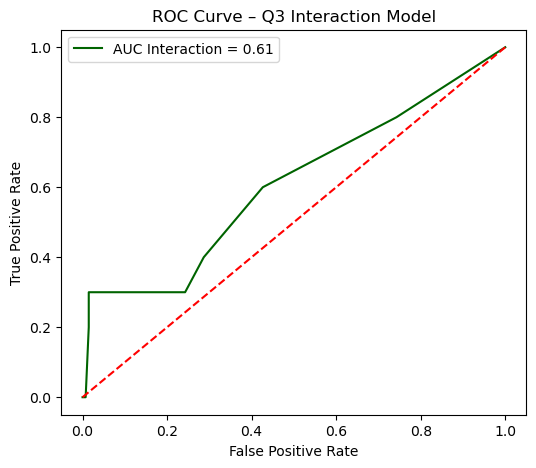

In [59]:
# ROC-AUC Test set (Interaction)
y_pred_prob_int = logit_interaction.predict(X_test_int)
auc_int = roc_auc_score(y_test, y_pred_prob_int)
print(auc_int)

# ROC curve
fpr_int, tpr_int, thresholds_int = roc_curve(y_test, y_pred_prob_int)

plt.figure(figsize=(6,5))
plt.plot(fpr_int, tpr_int, label=f"AUC Interaction = {auc_int:.2f}", color="darkgreen")
plt.plot([0,1], [0,1], "r--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Q3 Interaction Model")
plt.legend()
plt.show()

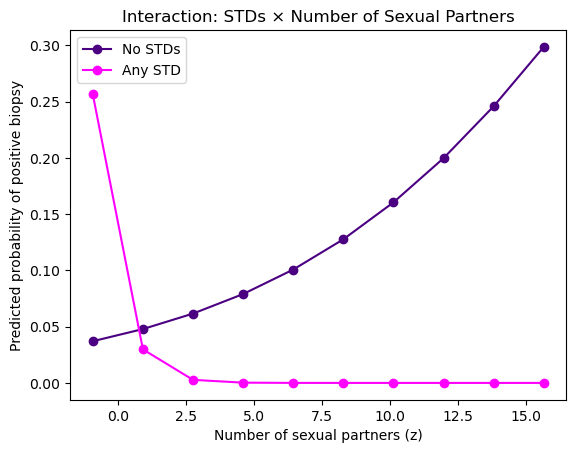

In [71]:
# How predicted biopsy probability changes across number of partners, separately for STD = 0 vs STD = 1.
partners_grid = np.linspace(risk_q3["num_partners_z"].min(), risk_q3["num_partners_z"].max(), 10) # Create 10 evenly spaced partner values spanning the full dataset range

# Isolating the effect of the interaction, setting smoking predictors to 0
plot_df = pd.DataFrame({
    "STDs": np.repeat([0,1], len(partners_grid)),
    "num_partners_z": list(partners_grid)*2, # 2 sequences
    "Smokes": 0,})

# Create interaction term to plot predicted probability
plot_df["stds_x_partners"] = plot_df["STDs"] * plot_df["num_partners_z"]
plot_df = sm.add_constant(plot_df)
plot_df["pred_prob"] = logit_interaction.predict(plot_df)

# Plot
for std_value, label, col in [(0,"No STDs","indigo"), (1,"Any STD","magenta")]:
    subset = plot_df[plot_df["STDs"] == std_value]
    plt.plot(subset["num_partners_z"], subset["pred_prob"],
             marker="o", label=label, color=col)

plt.xlabel("Number of sexual partners (z)")
plt.ylabel("Predicted probability of positive biopsy")
plt.title("Interaction: STDs × Number of Sexual Partners")
plt.legend();

In [60]:
# Sensitivity model - excluding smoking
X_train_sens = X_train.copy()
X_test_sens = X_test.copy()

# Dropping smoking variable
X_train_sens = X_train_sens.drop(columns=["Smokes"])
X_test_sens = X_test_sens.drop(columns=["Smokes"])

# Fitting model
logit_sens = sm.Logit(y_train, X_train_sens).fit()
print(logit_sens.summary())

# ORs + CIs
params_sens = logit_sens.params
conf_sens = logit_sens.conf_int()

or_table_sens = pd.DataFrame({
    "OR": np.exp(params_sens),
    "2.5%": np.exp(conf_sens[0]),
    "97.5%": np.exp(conf_sens[1])})

print(or_table_sens)

Optimization terminated successfully.
         Current function value: 0.252199
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                 Biopsy   No. Observations:                  583
Model:                          Logit   Df Residuals:                      580
Method:                           MLE   Df Model:                            2
Date:                Fri, 19 Dec 2025   Pseudo R-squ.:                0.008969
Time:                        03:09:58   Log-Likelihood:                -147.03
converged:                       True   LL-Null:                       -148.36
Covariance Type:            nonrobust   LLR p-value:                    0.2643
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -2.6880      0.180    -14.936      0.000      -3.041      -2.335
STDs             

0.6305147058823529


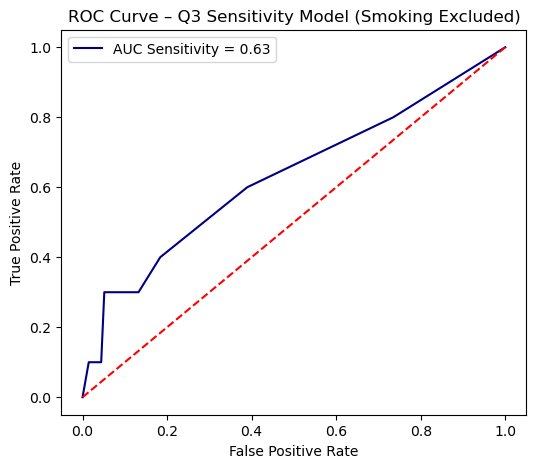

In [61]:
# ROC-AUC Test set (Sensitivity)
y_pred_prob_sens = logit_sens.predict(X_test_sens)
auc_sens = roc_auc_score(y_test, y_pred_prob_sens)
print(auc_sens)

# ROC curve 
fpr_sens, tpr_sens, thresholds_sens = roc_curve(y_test, y_pred_prob_sens)

plt.figure(figsize=(6,5))
plt.plot(fpr_sens, tpr_sens, label=f"AUC Sensitivity = {auc_sens:.2f}", color="navy")
plt.plot([0,1], [0,1], "r--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Q3 Sensitivity Model (Smoking Excluded)")
plt.legend()
plt.show()